# Device Heterogeneity Experiment

Measurement studies often assume a standard "Device Delay". In reality, a high-end flagship phone processes receipts faster than a low-end budget device. This notebook explores how hardware differences affect the RTT signature.

In [1]:
import sys
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Add simulator to path
sys.path.append(os.path.abspath("../simulator"))

from receipt_generator import ReceiptGenerator
from device_state_model import DeviceState, DeviceStateModel, DeviceStateProfile, DEFAULT_DEVICE_STATES
from network_delay_model import NetworkDelayModel, WIFI

## 1. Custom Device Profiles

We create custom profiles for three tiers of devices:
*   **Flagship**: Very fast processing.
*   **Mid-Range**: Standard/Default.
*   **Budget**: Slow CPU, high jitter.

In [2]:
def create_custom_model(tier_name, active_base, active_jitter):
    # Copy defaults but override ACTIVE state
    profiles = DEFAULT_DEVICE_STATES.copy()
    profiles[DeviceState.ACTIVE] = DeviceStateProfile(
        name=DeviceState.ACTIVE,
        base_delay_ms=active_base,
        jitter_ms=active_jitter,
        receipt_enabled=True
    )
    return DeviceStateModel(state_profiles=profiles, seed=42)

flagship_model = create_custom_model("Flagship", active_base=2, active_jitter=1)
midrange_model = create_custom_model("Mid-Range", active_base=15, active_jitter=10)
budget_model   = create_custom_model("Budget", active_base=40, active_jitter=25)

## 2. Comparing "Active" Across Tiers

We simulate "Active" users on all three devices, keeping the network constant (WiFi).

In [3]:
network_model = NetworkDelayModel(profile=WIFI, seed=123)
SAMPLES = 1000
results = []

scenarios = [
    ("Flagship", flagship_model),
    ("Mid-Range", midrange_model),
    ("Budget", budget_model)
]

for tier, dev_model in scenarios:
    generator = ReceiptGenerator(device_model=dev_model, network_model=network_model)
    for _ in range(SAMPLES):
        rtt = generator.generate_receipt(DeviceState.ACTIVE)
        if rtt:
            results.append({"Device Tier": tier, "RTT": rtt})

df = pd.DataFrame(results)

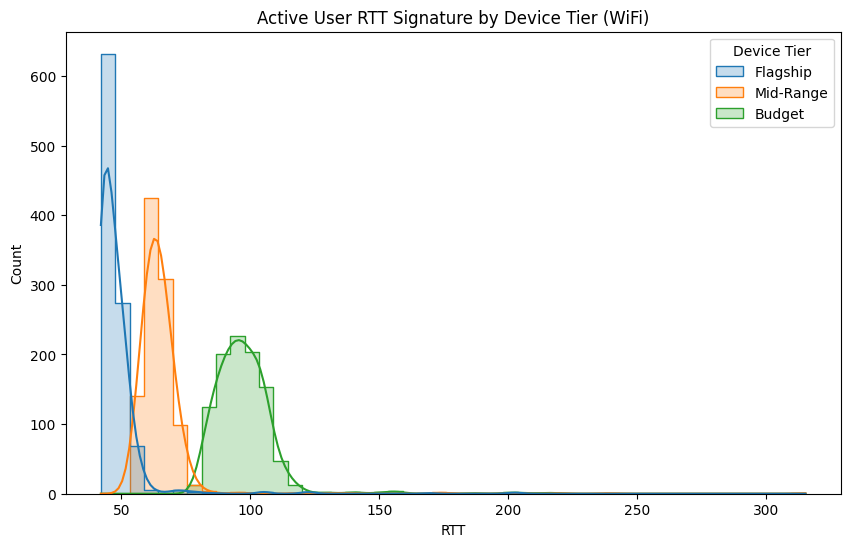

In [4]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x="RTT", hue="Device Tier", kde=True, element="step")
plt.title("Active User RTT Signature by Device Tier (WiFi)")
plt.show()

## 3. The Ambiguity Problem

Critically, look at the **Budget** Active distribution compared to a **Flagship** Idle/Background distribution (hypothetically).

If an attacker calibrates their model on a Flagship phone, they might misclassify a Budget phone's "Active" state as "Idle" because it is simply slower.

This highlights the need for **Per-Target Calibration** in side-channel attacks.